C:\Users\abhis\AppData\Local\Temp\ipykernel_27804\528846256.py:14: DtypeWarning: Columns (0,1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


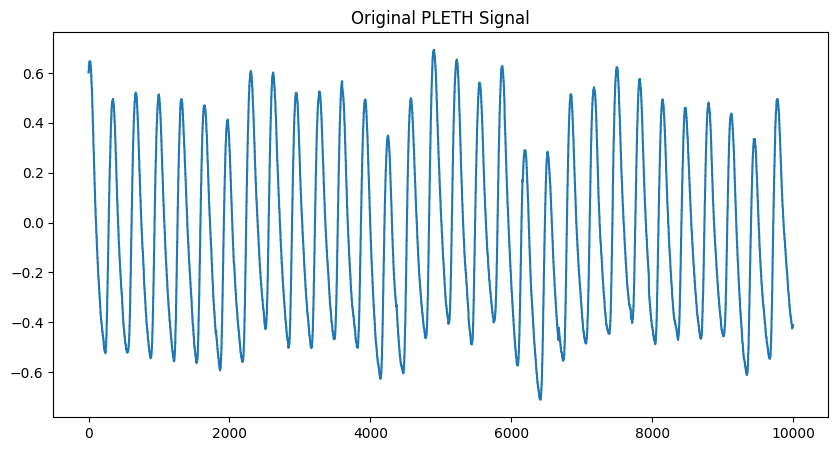

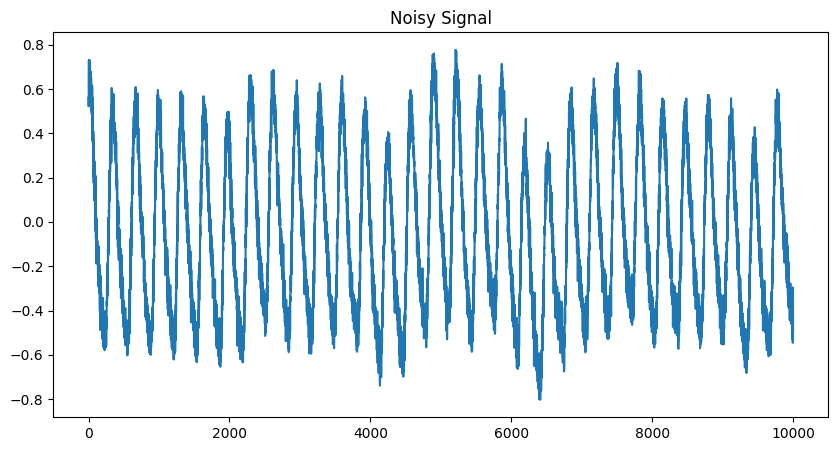

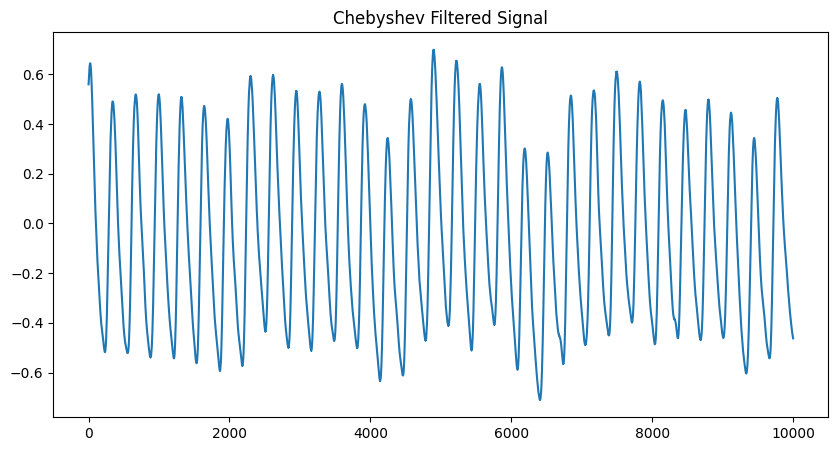

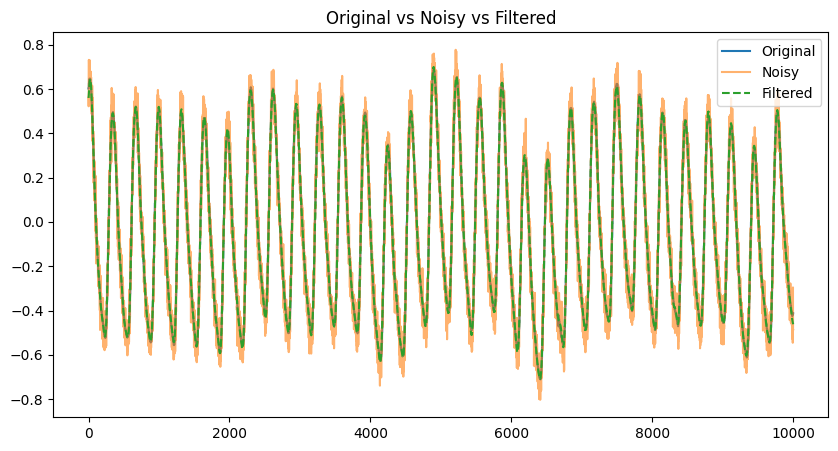

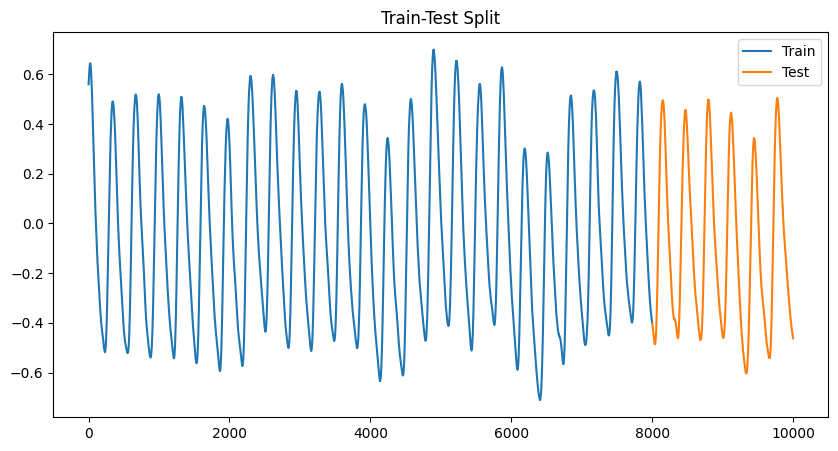

Epoch 1/10


c:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0939 - mae: 0.2575 - val_loss: 0.0024 - val_mae: 0.0390
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040 - mae: 0.0496 - val_loss: 0.0024 - val_mae: 0.0387
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - mae: 0.0494 - val_loss: 0.0024 - val_mae: 0.0394
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038 - mae: 0.0485 - val_loss: 0.0024 - val_mae: 0.0384
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0037 - mae: 0.0483 - val_loss: 0.0023 - val_mae: 0.0382
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - mae: 0.0489 - val_loss: 0.0024 - val_mae: 0.0392
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - mae: 0.0484 - val_loss: 0.0023 - val_mae: 0.0383
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038 - mae: 0.0486 - val_loss: 0.0024 - val_mae: 0.0387
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0036 

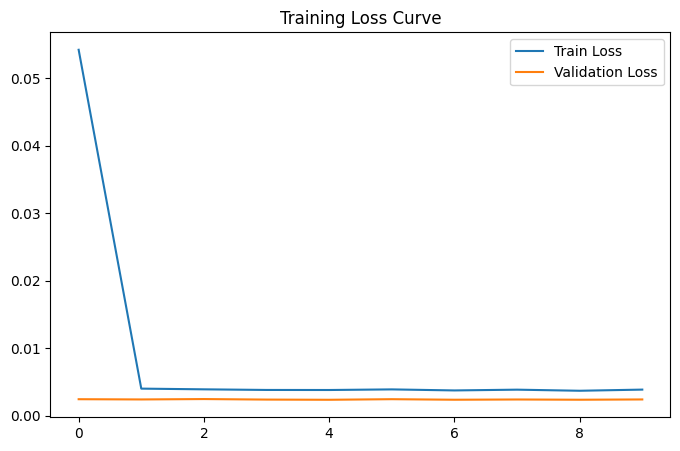

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


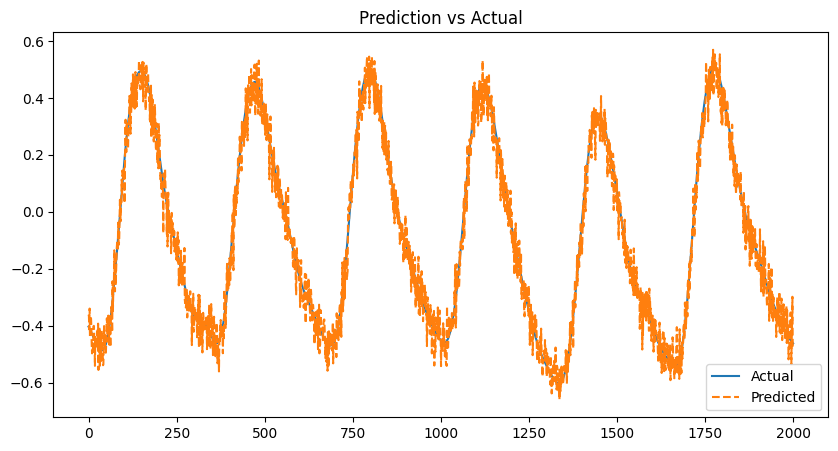

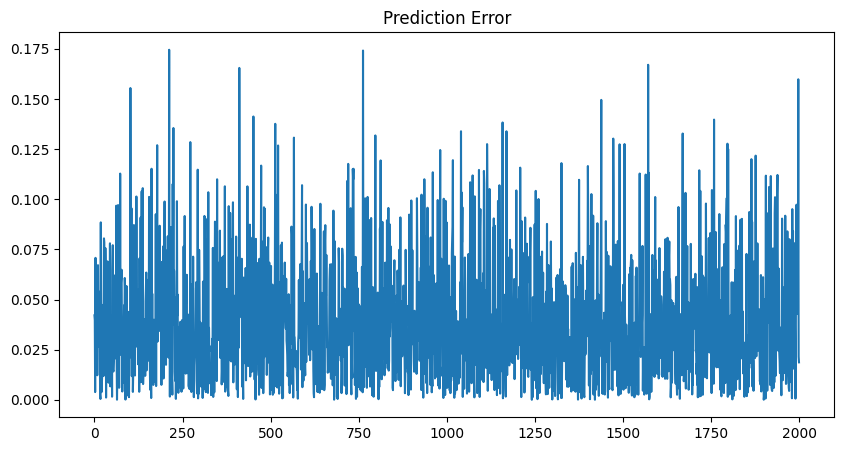

MSE: 0.0023815355805318645
MAE: 0.038569582995412154


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import cheby2, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =========================
# 1. LOAD DATASET
# =========================
file_path = "samples2.csv"
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip().str.replace("'", "").str.replace(" ", "")

# Convert to numeric and drop NaN
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# Take first 10,000 samples
df = df.iloc[:10000]

# =========================
# 2. EXTRACT SIGNAL
# =========================
pleth_signal = df["PLETH"].values

# =========================
# 3. ORIGINAL SIGNAL PLOT
# =========================
plt.figure(figsize=(10,5))
plt.plot(pleth_signal)
plt.title("Original PLETH Signal")
plt.show()

# =========================
# 4. ADD NOISE
# =========================
noise_std = 0.05
noisy_signal = pleth_signal + np.random.normal(0, noise_std, size=pleth_signal.shape)

# =========================
# 5. NOISY SIGNAL PLOT
# =========================
plt.figure(figsize=(10,5))
plt.plot(noisy_signal)
plt.title("Noisy Signal")
plt.show()

# =========================
# 6. CHEBYSHEV FILTER
# =========================
def cheby_filter(data, cutoff=2, fs=100, order=4, rs=20):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = cheby2(order, rs, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

cheby_output = cheby_filter(noisy_signal)

# =========================
# 7. FILTERED SIGNAL PLOT
# =========================
plt.figure(figsize=(10,5))
plt.plot(cheby_output)
plt.title("Chebyshev Filtered Signal")
plt.show()

# =========================
# 8. COMPARISON PLOT
# =========================
plt.figure(figsize=(10,5))
plt.plot(pleth_signal, label="Original")
plt.plot(noisy_signal, label="Noisy", alpha=0.6)
plt.plot(cheby_output, label="Filtered", linestyle='dashed')
plt.legend()
plt.title("Original vs Noisy vs Filtered")
plt.show()

# =========================
# 9. PREPARE DATA FOR LSTM
# =========================
X = noisy_signal.reshape(-1, 1, 1)
y = cheby_output.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# =========================
# 10. TRAIN-TEST SPLIT GRAPH
# =========================
plt.figure(figsize=(10,5))
plt.plot(y_train, label="Train")
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test, label="Test")
plt.legend()
plt.title("Train-Test Split")
plt.show()

# =========================
# 11. BUILD LSTM MODEL
# =========================
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(1,1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# =========================
# 12. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

# =========================
# 13. LOSS GRAPH
# =========================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.title("Training Loss Curve")
plt.show()

# =========================
# 14. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 15. PREDICTION GRAPH
# =========================
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted", linestyle='dashed')
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

# =========================
# 16. ERROR GRAPH
# =========================
error = np.abs(y_test - y_pred)

plt.figure(figsize=(10,5))
plt.plot(error)
plt.title("Prediction Error")
plt.show()

# =========================
# 17. METRICS
# =========================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")